In [1]:
# %pip install pyDOE

In [2]:
# from google.colab import drive #add the utilities and data folders to google drive
# drive.mount('/content/drive') #and mount it on google colab

In [3]:
# import sys
# sys.path.insert(0, '/content/drive/MyDrive/burgers_shock_mu_01_pi.mats') #upload utilities folder to your google drive before running the lines

In [4]:
# added validation loss 
# should I expect my NN weights to converge?
# check the seeds
# continue training until the val loss goes higer than training loss
# check if the derivation is correct.
# add regularization: l1, l2, dropout
import tensorflow as tf
import datetime, os
#hide tf logs 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'} 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#0 (default) shows all, 1 to filter out INFO logs, 2 to additionally filter out WARNING logs, and 3 to additionally filter out ERROR logs
import scipy.optimize
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
from pyDOE import lhs       #Latin Hypercube Sampling
# import lhs

# specify random seeds for reproducible results
# np.random.seed(4)
# tf.random.set_seed(4)

In [5]:
# data = scipy.io.loadmat('../content/drive/MyDrive/burgers_shock.mat')  	# Load data
data = scipy.io.loadmat('./data/burgers_shock_mu_005_pi.mat')  	# Load data
x = data['x']                                   # 256 points between -1 and 1 [256x1]
t = data['t']                                   # 100 time points between 0 and 1 [100x1] 
usol = data['usol']                             # solution of 256x100 grid points used only for testing (not for training)
X, T = np.meshgrid(x,t) 

In [6]:
X_u_test = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Domain bounds
lb = X_u_test[0]  # [-1. 0.]
ub = X_u_test[-1] # [1.  0.99]

'''
   Fortran Style ('F') flatten,stacked column wise!
   u = [c1 
        c2
        .
        .
        cn]

   u =  [25600x1] 
'''
u = usol.flatten('F')[:,None] # fortran style was used to make solution points compatible with (x,t) coordinate points

In [7]:
def trainingdata(N_u,N_f): ### randomize the choice on baoundary points

    '''Boundary Conditions'''

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None]

    all_X_u_train = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # X_u_train [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u_train = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #corresponding u [456x1]

    #choose random N_u points for training
    idx = np.random.choice(all_X_u_train.shape[0], N_u, replace=False) 

    X_u_train_rand = all_X_u_train[idx, :] #choose indices from  set 'idx' (x,t) #### randomize boundary point selection like in
    #### collocation points
    u_train_rand = all_u_train[idx,:]      #choose corresponding u

    '''Collocation Points'''

    # Latin Hypercube sampling for collocation points 
    # N_f sets of tuples(x,t)
    X_f_train = lb + (ub-lb)*lhs(2,N_f)
#     print(X_f_train.shape)
    X_f_train = np.vstack((X_f_train, X_u_train_rand)) # append training points to collocation points 

    return X_f_train, X_u_train_rand, u_train_rand 

def validationdata(N_u, N_f):

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None]

    all_X_u = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # X_u [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #corresponding u [456x1]

    #choose random N_u points for training
    idx = np.random.choice(all_X_u.shape[0], N_u, replace=False) #### the validation idx set has some mutual elements with the training idx set. make it exclusive.

    X_u_val_rand = all_X_u[idx, :] #choose indices from  set 'idx' (x,t) #### randomize boundary point selection like in
    #### collocation points
    u_val_rand = all_u[idx,:]      #choose corresponding u

    X_f_val = lb + (ub-lb)*lhs(2,N_f)

    X_f_val = np.vstack((X_f_val, X_u_val_rand)) # X_f_val includes the (x,t) coordinates of all the data. i.e. a small random set of boundary points plus a large set of collocation points. 

    return X_f_val, X_u_val_rand, u_val_rand 



In [8]:
class PINN(tf.Module): 
    def __init__(self, name=None):
        super().__init__(name = name)
        self.loss_history = np.array([])
        self.loss_val_history = np.array([])
        self.nu_history = np.array([])
        self.w_history = np.array([])
        self.nu = tf.Variable(1.2, dtype='float64', trainable = True)
        self.num_inter = 0
    
    def NN(self, layers = [2, 20, 20, 20, 20, 1]): ### if you need to get the weights from user, pass it to the
        ### pass it to the function. otherwise, do not pass the weights.
        ### for now set length of layers an even number.
        self.layers = layers
        self.W = []
        for i in range(len(layers)): ### enumerate
            if i==len(layers)-1: break
            w = tf.random.normal([layers[i],layers[i+1]], dtype = 'float64')
            w = tf.Variable(w, trainable = True)
            b = tf.zeros([1, layers[i+1]], dtype='float64', name=None) ### no bias for last output
            b = tf.Variable(b, trainable = True)
### edit tf.zeros for flexibility with other layer types
            self.W.append(w)
            self.W.append(b)
#         return W ### is return really necessary?
    
    def forward(self, inpu): ### do not specify input type
#         pass 
### try adding a normalization function 
        self.inpu = inpu
#         print('inpu.shape:', inpu.shape)
        inner = inpu
        for i, layer in enumerate(self.W):
            if i==len(self.W)/2 : break ### half of the length of layers ## lenth of W is always even so we don't care
                ## about the remnant of the devision.
#             print(i)
            inner = tf.matmul(inner, self.W[2*i])
            inner = tf.add(inner, self.W[2*i+1]) ### add activation function, now it's unit activation
            if i==len(self.W)/2-1: break # no activation for last layer
#         inner = tf.nn.tanh(inner) # bug: do not specify union function as activation coz the second derivative is zero
        # however, gradient tape returns none type and returns incompatibility type error for the rest of calculations
#         inner = tf.nn.relu(inner)
            inner = tf.math.sigmoid(inner)
        outpu = inner
        return outpu
        
    def PDE(self, X_f): 
        self.nu = self.trainable_variables[-1]
#         print(nu)
#         nu = 0.01/np.pi ### use it in callback and maybe in a tape.
        ### but i'm 70% sure it shouldn't be in the next callback as we try to treat it as a NN weight so scipy optimize
        ### will deal with it.
#         print('X_f in PDE:', X_f.shape)
        xt_var = tf.Variable(X_f, dtype='float64', trainable = False)
#         xt_var = tf.Variable(X_f, dtype='float64', trainable = False) ### try other dtypes here and in general
        ### check it it should be trainable
        # we meade a variable coz tape.gradient only takes the derivation of input with respect to a variable
        x_var = xt_var[:,0:1]
        t_var = xt_var[:,1:2]
#         print(x_var)
#         print(t_var)
        with tf.GradientTape(persistent = True) as tape1:
            tape1.watch(x_var)
            tape1.watch(t_var)
            with tf.GradientTape(persistent = True) as tape2:
                tape2.watch(x_var)
                tape2.watch(t_var)
                proxy_xt = tf.stack([x_var[:,0], t_var[:,0]], axis=1)
                u_pred = self.forward(proxy_xt)
            u_pred_x = tape2.gradient(u_pred, x_var) # gradient of u_pred with respect to x_var
        u_pred_t = tape2.gradient(u_pred, t_var) # gradient of u_pred with respect to x_var 
        u_pred_xt = tape1.gradient(u_pred_x, t_var) # gradient of u_pred_x with respect to t_var
        u_pred_xx = tape1.gradient(u_pred_x, x_var) # gradient of u_pred_x with respect to x_var
        # a general role for tape: specify one colomn arrays for avoiding complexity (esp for targets)
#         print('x_var')
#         print(x_var)
#         print('proxy_xt')
#         print(proxy_xt)
#         print('u_pred')
#         print(u_pred)
#         print('u_pred_x')
#         print(u_pred_x)
#         print('u_pred_t')
#         print(u_pred_t)
#         print('u_pred_xx')
#         print(u_pred_xx)
#         print('u_pred_xt')
#         print(u_pred_xt)
#         print(type(u_pred_xx))
        del tape1
        del tape2
        
#         u_pred_again = self.forward(proxy_xt) ### because everything after 'del tape' gets deleted but should we define it
        ### again?
        
        f = u_pred_t + u_pred*u_pred_x - self.nu*u_pred_xx
#         print(u_pred_xx.shape)
        
        return f

    def PPDE(self, X_f): ### it's the same as PDE except that the source of gradient has 2 column
        xt_var = tf.Variable(X_f, dtype='float64', trainable = False)
        ### try other dtypes here and in general
        # we made a variable coz tape.gradient only takes the derivation of input with respect to a variable
#         x_var = xt_var[:,0:1]
#         t_var = xt_var[:,1:2]
        with tf.GradientTape(persistent = True) as tape1:
            tape1.watch(xt_var)
            with tf.GradientTape(persistent = True) as tape2:
                tape2.watch(xt_var)
#                 tape2.watch(x_var)
#                 tape2.watch(t_var)
#                 proxy_xt = tf.stack([x_var[:,0], t_var[:,0]], axis=1)
                u_pred = self.forward(xt_var)
            u_pred_x = tape2.gradient(u_pred, xt_var)[:,0:1] # gradient of u_pred with respect to x_var
            u_pred_t = tape2.gradient(u_pred, xt_var)[:,1:2] # gradient of u_pred with respect to t_var
        u_pred_xx_xt = tape1.gradient(u_pred_x, xt_var) # gradient of u_pred_x with respect to both x and t
        u_pred_xx = u_pred_xx_xt[:,0:1]
        u_pred_xt = u_pred_xx_xt[:,1:2]
#         print('xt_var')
#         print(xt_var)
#         print('u_pred')
#         print(u_pred)
#         print('u_pred_x')
#         print(u_pred_x)
#         print('u_pred_t')
#         print(u_pred_t)
#         print('u_pred_xx_xt')
#         print(u_pred_xx_xt)
#         print('u_pred_xx')
#         print(u_pred_xx)
#         print('u_pred_xt')
#         print(u_pred_xt)
#         print(type(u_pred_xx))
#         u_pred_t = tape.gradient(u_pred, t_var) # gradient of u_pred with respect to x_var
        del tape1
        del tape2

#         u_pred_again = self.forward(proxy_xt) ### because everything after 'del tape' gets deleted but should we define it
#         ### again?

        f = u_pred_t + u_pred_again*u_pred_x - nu*u_pred_xx

        return f

    def loss(self, X_f, X_u, u):
        X_u = tf.Variable(X_u, dtype='float64', trainable = False)
        u = tf.Variable(u, dtype='float64', trainable = False)
        e_DD = self.forward(X_u) - u
        loss_DD = tf.reduce_mean(tf.square(e_DD))
        
        f = self.PDE(X_f)
        loss_PI = tf.reduce_mean(tf.square(f)) # physics-informed loss

        loss_nu = tf.square(self.nu)
        loss_w_l2 = tf.reduce_mean(tf.square(self.get_weights()))
        loss_w_l1 = tf.reduce_mean(tf.abs(self.get_weights()))

        # loss = 0.5 * loss_PI + 0.5 * loss_DD ### try different weights
        loss = 0.5 * loss_PI + 0.5 * loss_DD 
        ### add an extra term in the loss for training loss in the collocation. it should be exactly the same as boundary.
        return loss, loss_DD, loss_PI

    def loss_val(self, X_f, X_u, u):
        X_u = tf.Variable(X_u, dtype='float64', trainable = False)
        u = tf.Variable(u, dtype='float64', trainable = False)
        e_DD = self.forward(X_u) - u
        loss_DD = tf.reduce_mean(tf.square(e_DD))
        
        f = self.PDE(X_f)
        loss_PI = tf.reduce_mean(tf.square(f)) # physics-informed loss

        loss_nu = tf.square(self.nu) 
        loss_w_l2 = tf.reduce_mean(tf.square(self.get_weights()))
        loss_w_l1 = tf.reduce_mean(tf.abs(self.get_weights()))

        # loss = 0.5 * loss_PI + 0.5 * loss_DD ### try different weights
        loss = 0.5 * loss_PI + 0.5 * loss_DD 
        ### add an extra term in the loss for training loss in the collocation. it should be exactly the same as boundary.
        return loss, loss_DD, loss_PI    
    
    def set_weights(self,parameters):
                
        for i in range (len(self.layers)-1):

            shape_w = tf.shape(self.W[2*i]).numpy() # shape of the weight tensor
            size_w = tf.size(self.W[2*i]).numpy() #size of the weight tensor 
            
            shape_b = tf.shape(self.W[2*i+1]).numpy() # shape of the bias tensor
            size_b = tf.size(self.W[2*i+1]).numpy() #size of the bias tensor 
                        
            pick_w = parameters[0:size_w] #pick the weights 
            self.W[2*i].assign(tf.reshape(pick_w,shape_w)) # assign  
            parameters = np.delete(parameters,np.arange(size_w),0) #delete 
            
            pick_b = parameters[0:size_b] #pick the biases 
            self.W[2*i+1].assign(tf.reshape(pick_b,shape_b)) # assign 
            parameters = np.delete(parameters,np.arange(size_b),0) #delete
        
        self.nu.assign(parameters[-1]) # the last parameter is the pde parameter. try adding several parameters
        
    def get_weights(self):

        parameters_1d = []  # [.... W_i,b_i.....  ] 1d array
        
        for i in range (len(self.layers)-1):
            
            w_1d = tf.reshape(self.W[2*i],[-1])   #flatten weights 
            b_1d = tf.reshape(self.W[2*i+1],[-1]) #flatten biases
            
            parameters_1d = tf.concat([parameters_1d, w_1d], 0) #concat weights 
            parameters_1d = tf.concat([parameters_1d, b_1d], 0) #concat biases
            
        nu_1d = tf.reshape(self.nu,[-1])    #flatten pde params 
        parameters_1d = tf.concat([parameters_1d, nu_1d], 0) #concat pde params
        return parameters_1d    
        
    
    def backward(self,parameters): # this is where the loss and gradients of loss are produced.
        self.set_weights(parameters) # sets weights as a matrix

        with tf.GradientTape() as tape:
            tape.watch(self.trainable_variables)

            loss, _, _ = self.loss(X_f_train, X_u_train, u_train) ### can we solve the problem with just loss_DD or loss_PI?

        grads = tape.gradient(loss, self.trainable_variables) ### includes nu, which is the last parameter

        del tape

        grads_1d = [ ] #flatten grads 
        
        # so far the grads are in matrix form, by the following loop we'll change it to 1 dimentional array. 
        ### because scipy.optimize speaks in the language of one dimnetional arrays
        for i in range(len(self.layers)-1):

            grads_w_1d = tf.reshape(grads[2*i],[-1]) #flatten weights 
            grads_b_1d = tf.reshape(grads[2*i+1],[-1]) #flatten biases

            grads_1d = tf.concat([grads_1d, grads_w_1d], 0) #concat grad_weights 
            grads_1d = tf.concat([grads_1d, grads_b_1d], 0) #concat grad_biases
            
        grads_nu_1d = tf.reshape(grads[-1],[-1])
        grads_1d = tf.concat([grads_1d, grads_nu_1d], 0)
        return loss.numpy(), grads_1d.numpy()
    
    def callback(self, parameters):
        self.num_inter += 1
               
        loss, _, _ = self.loss(X_f_train, X_u_train, u_train)
        loss_np = loss.numpy()
        nu_np = self.nu.numpy()
        
        self.loss_history = np.append(self.loss_history, loss_np)
        self.nu_history = np.append(self.nu_history, nu_np)
        self.w_history = np.append(self.w_history, self.W[0][0][0]) ### putting the probe on a single weight amongst all.

        loss_val, _, _ = self.loss_val(X_f_val, X_u_val, u_val)
        loss_val_np = loss_val.numpy()
        self.loss_val_history = np.append(self.loss_val_history, loss_val_np)
        
        print('num_inter:', self.num_inter, '\t', 'nu_np:', nu_np, '\t', 'loss:', loss_np, '\t', 'loss_val', loss_val_np)

        
## add the pde paramter to PDE()       

In [9]:
pinn = PINN(name='first')
nn = pinn.NN(layers = [2, 20, 20, 20, 20, 1]) # initializing nn weights and biases # number of layers N=5
### it's best to try initializing the PDE param as well.
# for i in range(len(pinn.W)):
#     print(pinn.W[i].shape)


In [10]:
N_u = 100
N_f = 10000
X_f_train, X_u_train, u_train = trainingdata(N_u, N_f) 
X_f_val, X_u_val, u_val = validationdata(N_u, N_f)
init_params = pinn.get_weights().numpy()

In [11]:
X_f_train

array([[ 0.72439552,  0.39889602],
       [-0.63503401,  0.95595586],
       [ 0.94060936,  0.12010852],
       ...,
       [ 0.97647059,  0.        ],
       [ 0.96078431,  0.        ],
       [ 1.        ,  0.44      ]])

In [12]:
X_f_val

array([[ 0.41262909,  0.73455739],
       [-0.69183794,  0.15141687],
       [-0.23709677,  0.80410981],
       ...,
       [ 0.24705882,  0.        ],
       [-1.        ,  0.63      ],
       [ 1.        ,  0.02      ]])

In [13]:
t_start = time.time()
results = scipy.optimize.minimize(fun = pinn.backward, 
                                  x0 = init_params, 
                                  args=(), 
                                  method='L-BFGS-B', 
                                  jac= True,
                                  callback = pinn.callback,
                                  options = {'disp': None,
                                            'maxcor': 200, 
                                            'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
                                            'gtol': 5e-8, 
                                            'maxfun':  50000, 
                                            'maxiter': 5000,
                                            'iprint': -1,   #print update every 50 iterations
                                            'maxls': 50})
run_time = time.time() - t_start 
print('run_time (min):', run_time/60.0)

num_inter: 1 	 nu_np: 1.1961449544579064 	 loss: 1.6125005562655916 	 loss_val 1.6028843556793684
num_inter: 2 	 nu_np: 1.196513645480445 	 loss: 0.1516488314420419 	 loss_val 0.15876730234038414
num_inter: 3 	 nu_np: 1.1954879249222998 	 loss: 0.1491535374385554 	 loss_val 0.1566644572752399
num_inter: 4 	 nu_np: 1.1935374549667503 	 loss: 0.14716811339509625 	 loss_val 0.15462110729304865
num_inter: 5 	 nu_np: 1.1837467550609828 	 loss: 0.14026692924950318 	 loss_val 0.14681046800964748
num_inter: 6 	 nu_np: 1.1691183684371573 	 loss: 0.13296575951131095 	 loss_val 0.1379085497145573
num_inter: 7 	 nu_np: 1.115116278088006 	 loss: 0.11958423626749799 	 loss_val 0.12219886713826095
num_inter: 8 	 nu_np: 1.0683930567148205 	 loss: 0.11565477109139766 	 loss_val 0.11348819065320155
num_inter: 9 	 nu_np: 1.0705397563299965 	 loss: 0.11413849326373973 	 loss_val 0.11318353886769368
num_inter: 10 	 nu_np: 1.062925976941107 	 loss: 0.11368915579016159 	 loss_val 0.11264063289696523
num_inte

num_inter: 82 	 nu_np: 0.17680970372563803 	 loss: 0.005717254785075739 	 loss_val 0.0074004943032511695
num_inter: 83 	 nu_np: 0.18446042524466447 	 loss: 0.005585018696952037 	 loss_val 0.007121463679182269
num_inter: 84 	 nu_np: 0.18625234314555558 	 loss: 0.005505741732393386 	 loss_val 0.0069650834395857016
num_inter: 85 	 nu_np: 0.18750769869756242 	 loss: 0.0054454454001984535 	 loss_val 0.006886603114665609
num_inter: 86 	 nu_np: 0.1890070347621104 	 loss: 0.00538591567109552 	 loss_val 0.0067645421583498976
num_inter: 87 	 nu_np: 0.19389639838433675 	 loss: 0.005272894284271832 	 loss_val 0.006552180462265522
num_inter: 88 	 nu_np: 0.1996304282835252 	 loss: 0.005148680697557681 	 loss_val 0.006246875869947301
num_inter: 89 	 nu_np: 0.20759742510548562 	 loss: 0.005042842198976974 	 loss_val 0.006143596002852303
num_inter: 90 	 nu_np: 0.2106014093500464 	 loss: 0.004894167661608618 	 loss_val 0.006051500176394392
num_inter: 91 	 nu_np: 0.2152961454954567 	 loss: 0.004744737433

num_inter: 161 	 nu_np: 0.2760728757805955 	 loss: 0.0025792810652916012 	 loss_val 0.0034860254109228828
num_inter: 162 	 nu_np: 0.2789325531960624 	 loss: 0.0025494241951210324 	 loss_val 0.0034424540945914633
num_inter: 163 	 nu_np: 0.2835880790427951 	 loss: 0.002501024914243452 	 loss_val 0.003353900216508485
num_inter: 164 	 nu_np: 0.2940837332993199 	 loss: 0.0024238237812944405 	 loss_val 0.003202743672810228
num_inter: 165 	 nu_np: 0.2954179761489797 	 loss: 0.002390619080275069 	 loss_val 0.003190158642839094
num_inter: 166 	 nu_np: 0.2940293620790396 	 loss: 0.0023279143811778314 	 loss_val 0.003107418902212239
num_inter: 167 	 nu_np: 0.29536979484442244 	 loss: 0.0022842537314140756 	 loss_val 0.003067377456049417
num_inter: 168 	 nu_np: 0.3033030708222322 	 loss: 0.002256095417953375 	 loss_val 0.0030064746662773634
num_inter: 169 	 nu_np: 0.3044301667884606 	 loss: 0.0022466220127306505 	 loss_val 0.002964728182981295
num_inter: 170 	 nu_np: 0.30379771310106596 	 loss: 0.

num_inter: 239 	 nu_np: 0.4592829474125213 	 loss: 0.0015016375976601832 	 loss_val 0.0019002025549916617
num_inter: 240 	 nu_np: 0.466109634185329 	 loss: 0.0014843836241405653 	 loss_val 0.0018717629261978139
num_inter: 241 	 nu_np: 0.47514732769817886 	 loss: 0.0014781806915695446 	 loss_val 0.0018721517744877947
num_inter: 242 	 nu_np: 0.47639264615411836 	 loss: 0.0014552475869949503 	 loss_val 0.001852168174289313
num_inter: 243 	 nu_np: 0.4752401562087073 	 loss: 0.0014456221138682414 	 loss_val 0.0018346586811098177
num_inter: 244 	 nu_np: 0.4798249081245191 	 loss: 0.0014368362853819996 	 loss_val 0.0018265339962063427
num_inter: 245 	 nu_np: 0.4774590205430291 	 loss: 0.0014297471653365072 	 loss_val 0.001819547077822578
num_inter: 246 	 nu_np: 0.47823573937136854 	 loss: 0.0014229143674503349 	 loss_val 0.0018100002984212378
num_inter: 247 	 nu_np: 0.4792309650808967 	 loss: 0.001416200237436075 	 loss_val 0.0018097327142567662
num_inter: 248 	 nu_np: 0.477018229099585 	 los

num_inter: 317 	 nu_np: 0.4832832266193035 	 loss: 0.0010005355810314993 	 loss_val 0.0013167594073683808
num_inter: 318 	 nu_np: 0.4839648305382812 	 loss: 0.0009939936326800029 	 loss_val 0.0012995432076665682
num_inter: 319 	 nu_np: 0.4833918086005828 	 loss: 0.0009853042618405729 	 loss_val 0.0012756392479556147
num_inter: 320 	 nu_np: 0.48234190073828015 	 loss: 0.0009787180150860322 	 loss_val 0.0012755952324709214
num_inter: 321 	 nu_np: 0.4844437181206277 	 loss: 0.0009722558080975587 	 loss_val 0.001281213378450897
num_inter: 322 	 nu_np: 0.49044881026059417 	 loss: 0.0009660220538119636 	 loss_val 0.001241059554573681
num_inter: 323 	 nu_np: 0.49157070643374556 	 loss: 0.0009573731783803243 	 loss_val 0.0012444584590082528
num_inter: 324 	 nu_np: 0.49316828291472226 	 loss: 0.0009516349098079868 	 loss_val 0.001274094197101726
num_inter: 325 	 nu_np: 0.49738336520356646 	 loss: 0.0009439428114559734 	 loss_val 0.0012481230246641822
num_inter: 326 	 nu_np: 0.5021145742985595 	

...

num_inter: 4627 	 nu_np: 2.647735853818951 	 loss: 4.22398166171505e-06 	 loss_val 1.2326794969903373e-05
num_inter: 4628 	 nu_np: 2.647467325920249 	 loss: 4.223074608936932e-06 	 loss_val 1.2355468274736884e-05
num_inter: 4629 	 nu_np: 2.6473412946545745 	 loss: 4.222110763263377e-06 	 loss_val 1.2369633593723964e-05
num_inter: 4630 	 nu_np: 2.6480313445925963 	 loss: 4.2209362251815625e-06 	 loss_val 1.2391640116517206e-05
num_inter: 4631 	 nu_np: 2.646611138374808 	 loss: 4.220558090981017e-06 	 loss_val 1.2437128797067004e-05
num_inter: 4632 	 nu_np: 2.6476579924667436 	 loss: 4.219446652271549e-06 	 loss_val 1.2423879413520476e-05
num_inter: 4633 	 nu_np: 2.648563641312289 	 loss: 4.218707078288191e-06 	 loss_val 1.2391899759933865e-05
num_inter: 4634 	 nu_np: 2.6486735625496163 	 loss: 4.2173924307355765e-06 	 loss_val 1.2416746105665587e-05
num_inter: 4635 	 nu_np: 2.6496021402524788 	 loss: 4.215444403832044e-06 	 loss_val 1.2440083417868278e-05
num_inter: 4636 	 nu_np: 2.6513

num_inter: 4704 	 nu_np: 2.725446650151409 	 loss: 4.111640373576798e-06 	 loss_val 1.2204060145416065e-05
num_inter: 4705 	 nu_np: 2.7257180132347276 	 loss: 4.110274293424379e-06 	 loss_val 1.2201088510461561e-05
num_inter: 4706 	 nu_np: 2.7269825830689767 	 loss: 4.109318103990649e-06 	 loss_val 1.2215890121183308e-05
num_inter: 4707 	 nu_np: 2.7266413485124104 	 loss: 4.108081224393411e-06 	 loss_val 1.2207252744031558e-05
num_inter: 4708 	 nu_np: 2.727153710297929 	 loss: 4.1072159426041385e-06 	 loss_val 1.2146130663340465e-05
num_inter: 4709 	 nu_np: 2.7274073079873897 	 loss: 4.106684874015718e-06 	 loss_val 1.2141454325167656e-05
num_inter: 4710 	 nu_np: 2.727768672424137 	 loss: 4.106469986983672e-06 	 loss_val 1.2130889511347083e-05
num_inter: 4711 	 nu_np: 2.727921244152213 	 loss: 4.106241039033962e-06 	 loss_val 1.210948391816908e-05
num_inter: 4712 	 nu_np: 2.7281278279784273 	 loss: 4.1061181891886e-06 	 loss_val 1.2097605318367495e-05
num_inter: 4713 	 nu_np: 2.7281946

num_inter: 4781 	 nu_np: 2.722621255114642 	 loss: 4.0415695631773045e-06 	 loss_val 1.2019451476715755e-05
num_inter: 4782 	 nu_np: 2.72075751938083 	 loss: 4.041265189852641e-06 	 loss_val 1.20232667465155e-05
num_inter: 4783 	 nu_np: 2.7228216446260283 	 loss: 4.039702892231188e-06 	 loss_val 1.1983716557429244e-05
num_inter: 4784 	 nu_np: 2.721492528119088 	 loss: 4.038913061040171e-06 	 loss_val 1.2002335008502899e-05
num_inter: 4785 	 nu_np: 2.7210076187822168 	 loss: 4.037769511214998e-06 	 loss_val 1.2021844752948418e-05
num_inter: 4786 	 nu_np: 2.7195705272855415 	 loss: 4.036450193662441e-06 	 loss_val 1.2029281295037993e-05
num_inter: 4787 	 nu_np: 2.7188866073688907 	 loss: 4.035811768329084e-06 	 loss_val 1.2040269774397205e-05
num_inter: 4788 	 nu_np: 2.7190118577752838 	 loss: 4.0350320142489055e-06 	 loss_val 1.205053507648642e-05
num_inter: 4789 	 nu_np: 2.7177069794531317 	 loss: 4.034177204891536e-06 	 loss_val 1.2057577598623757e-05
num_inter: 4790 	 nu_np: 2.718385

num_inter: 4858 	 nu_np: 2.7543727253242007 	 loss: 3.843169793696205e-06 	 loss_val 1.1512429548645105e-05
num_inter: 4859 	 nu_np: 2.7538801757577467 	 loss: 3.840358839364205e-06 	 loss_val 1.1627744734619572e-05
num_inter: 4860 	 nu_np: 2.7536374241645234 	 loss: 3.837918942323049e-06 	 loss_val 1.1652658113609091e-05
num_inter: 4861 	 nu_np: 2.7542824140733826 	 loss: 3.8359879487040395e-06 	 loss_val 1.1669057618817821e-05
num_inter: 4862 	 nu_np: 2.75638563777479 	 loss: 3.835893454809461e-06 	 loss_val 1.167230661556617e-05
num_inter: 4863 	 nu_np: 2.7565347258440442 	 loss: 3.83274667258831e-06 	 loss_val 1.1634240585638353e-05
num_inter: 4864 	 nu_np: 2.7565753230077936 	 loss: 3.8319995142095285e-06 	 loss_val 1.1629985764773732e-05
num_inter: 4865 	 nu_np: 2.7571008337197758 	 loss: 3.8288827181902005e-06 	 loss_val 1.1647018738299675e-05
num_inter: 4866 	 nu_np: 2.758427417312012 	 loss: 3.826785140029554e-06 	 loss_val 1.163379559598874e-05
num_inter: 4867 	 nu_np: 2.7596

num_inter: 4935 	 nu_np: 2.852318957649182 	 loss: 3.6396679505037856e-06 	 loss_val 1.0497503747819784e-05
num_inter: 4936 	 nu_np: 2.853305672083222 	 loss: 3.6390780723996603e-06 	 loss_val 1.0474942953613914e-05
num_inter: 4937 	 nu_np: 2.8538247336783105 	 loss: 3.63856179454641e-06 	 loss_val 1.0469843184316362e-05
num_inter: 4938 	 nu_np: 2.8541940083274784 	 loss: 3.637665305086595e-06 	 loss_val 1.0464206581975747e-05
num_inter: 4939 	 nu_np: 2.854972185744006 	 loss: 3.6362505444981405e-06 	 loss_val 1.0462891401618122e-05
num_inter: 4940 	 nu_np: 2.8548524206504404 	 loss: 3.6350828189144257e-06 	 loss_val 1.0459274650074116e-05
num_inter: 4941 	 nu_np: 2.8563047780804967 	 loss: 3.633872799319231e-06 	 loss_val 1.0444284095494647e-05
num_inter: 4942 	 nu_np: 2.8554985021406027 	 loss: 3.631622410244622e-06 	 loss_val 1.0480096242540607e-05
num_inter: 4943 	 nu_np: 2.856513632620067 	 loss: 3.6291590306017057e-06 	 loss_val 1.0455668690860266e-05
num_inter: 4944 	 nu_np: 2.8

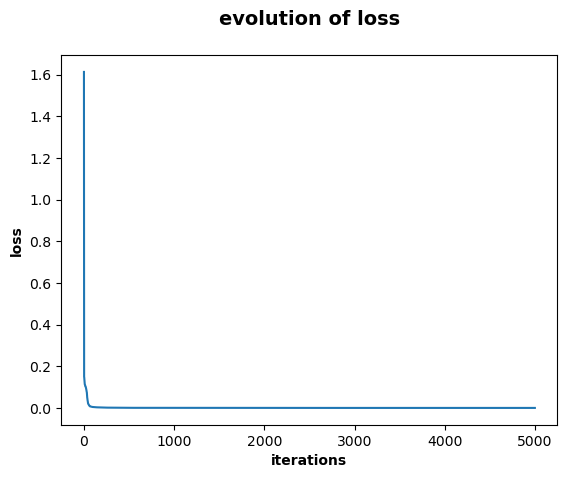

In [14]:
fig, ax = plt.subplots()  
ax.plot(pinn.loss_history)
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss.png')
plt.show()

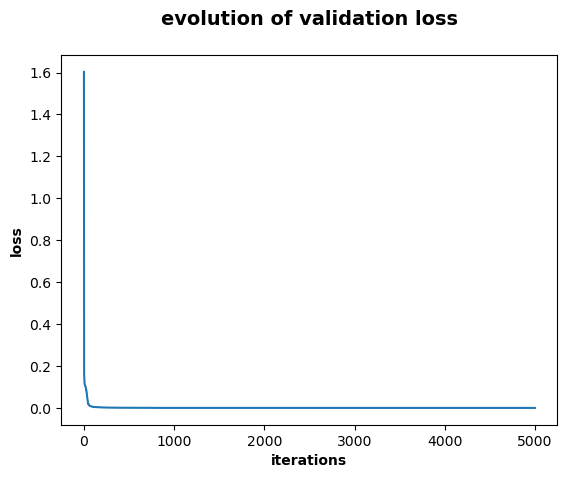

In [15]:
fig, ax = plt.subplots()  
ax.plot(pinn.loss_val_history)
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of validation loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss_val.png')
plt.show()

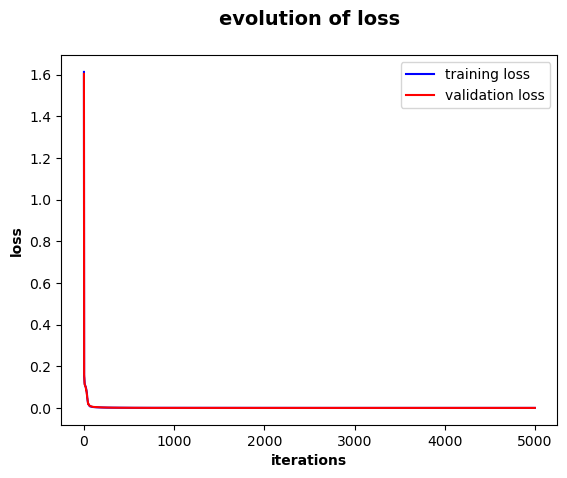

In [16]:
fig, ax = plt.subplots()  
ax.plot(pinn.loss_history, 'b')
ax.plot(pinn.loss_val_history, 'r')
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss.png')
plt.legend(['training loss', 'validation loss'])
plt.show()

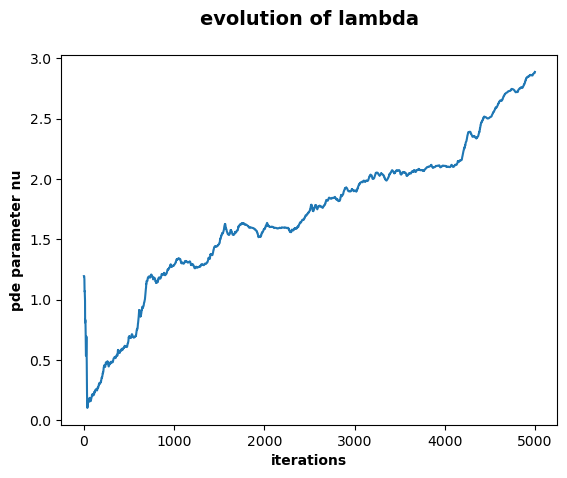

In [17]:
fig, ax = plt.subplots()  
ax.plot(pinn.nu_history)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('pde parameter nu', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of lambda\n', fontsize = 14, fontweight ='bold')
plt.savefig('nu.png')
plt.show()

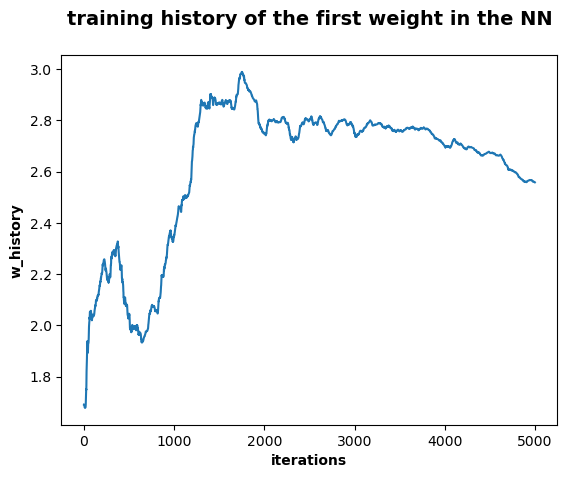

In [18]:
fig, ax = plt.subplots()  
ax.plot(pinn.w_history)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('w_history', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('training history of the first weight in the NN\n', fontsize = 14, fontweight ='bold')
plt.savefig('w0.png')
plt.show()

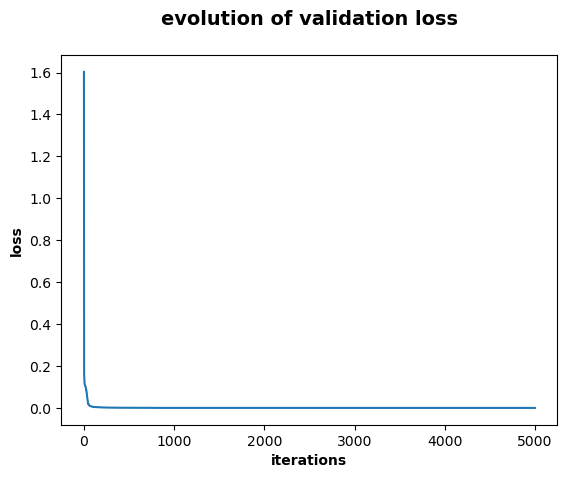

In [19]:
fig, ax = plt.subplots()  
ax.plot(pinn.loss_val_history)
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of validation loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss_val.png')
plt.show()

In [20]:
# from google.colab import files
# files.download("loss.png")
# files.download("nu.png")
# files.download("w0.png")

In [21]:
X_u_test.shape

(25600, 2)

In [22]:
len(pinn.trainable_variables)

11

In [23]:
len(pinn.W)

10

In [24]:
pinn.trainable_variables[-1]

<tf.Variable 'Variable:0' shape=() dtype=float64, numpy=2.8865338792573203>

In [25]:
pinn.trainable_variables

(<tf.Variable 'Variable:0' shape=(2, 20) dtype=float64, numpy=
 array([[ 2.55816035, -0.05424535,  1.11647935,  1.79379682, -0.05893904,
         -0.27453605,  2.09682117, -1.79461288,  3.4262611 ,  1.35239281,
          1.12907984,  1.99271755, -0.50346026,  0.26986495,  0.7603975 ,
         -0.40985338, -0.30345003,  2.06233083,  0.92250194, -2.57008642],
        [ 3.85951683, -5.70693961,  1.67140367, -2.67924451, 10.13512946,
         -1.99445381, -2.82376403,  3.05285266,  2.60510005,  0.53457957,
          1.76941491, -3.47037657,  6.66651829,  9.26397685, -9.62217642,
          6.45680449,  4.48490656,  4.96820393, -4.62080307, -2.16091709]])>,
 <tf.Variable 'Variable:0' shape=(1, 20) dtype=float64, numpy=
 array([[-4.23031699, -0.83801746, -0.70230659, -3.61098985, -1.8648353 ,
          0.07325709,  0.04344583,  0.66637922,  5.66842905, -0.17227977,
         -1.08720485,  0.93290773,  1.85190098,  0.41427679, -0.94527897,
         -0.93706247, -1.23885352,  4.36891006, -1.0215